# Test Models under different configurations

In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from scipy.stats import sem
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [2]:
# --- Fetch dataset ---
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)
X = cdc_diabetes_health_indicators.data.features
Y = cdc_diabetes_health_indicators.data.targets
y = Y.values.ravel()

Use results from previous feature selection

In [3]:
# --- Feature Types ---
binary_features = [
    'HighBP',
    'HighChol',
    'CholCheck',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Fruits',
    'Veggies',
    'HvyAlcoholConsump',
    'AnyHealthcare',
    'NoDocbcCost',
    'DiffWalk',
    'Sex'
]
ordinal_features = ['GenHlth',
                    'Age',
                    'Education',
                    'Income'
                    ]
ratio_features = ['BMI',
                  'MentHlth',
                  'PhysHlth'
                  ]

# --- After Feature Selection ---
selected_columns = ['HighBP', 'HighChol', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth']


In [4]:
# --- Preprocessing Pipeline ---
ordinal_encoder = OrdinalEncoder()
scaler = StandardScaler()
preprocessor = ColumnTransformer([
    ('ordinal', ordinal_encoder, ordinal_features),
    ('ratio', scaler, ratio_features)
], remainder='passthrough')

In [5]:
# --- Model Definitions ---
model_dict = {
    "XGB": XGBClassifier(eval_metric='logloss'),
    "RF": RandomForestClassifier(),
    "GBC": GradientBoostingClassifier(),
    "LGBM": LGBMClassifier(verbose=-1),
    "KNN": KNeighborsClassifier()
}

Define different configurations of specified models:

In [6]:
# --- Hyperparameter Grids ---
grids = {
    "XGB": {'model__n_estimators': [50, 100], 'model__max_depth': [3, 6], 'model__learning_rate': [0.05, 0.1]},
    "RF": {'model__n_estimators': [50, 100], 'model__max_depth': [None, 10]},
    "GBC": {'model__n_estimators': [50, 100], 'model__learning_rate': [0.05, 0.1]},
    "LGBM": {'model__n_estimators': [50, 100], 'model__num_leaves': [31, 50], 'model__learning_rate': [0.05, 0.1]},
    "KNN": {'model__n_neighbors': [3, 5, 7]}
}

Also define different configurations of model evaluation:
1. Using different train/test split ratios and cross validation
2. Using different methods to balance dataset: Undersampling, Oversampling and No Balancing


In [ ]:
# --- Sampling and Splitting Config ---
split_configs = [0.2, 0.3, "cv"]
samplers = {
    "Undersampling": RandomUnderSampler(random_state=42),
    "Oversampling": SMOTE(random_state=42),
    "None": None
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # for imbalanced datasets

In [8]:
# --- Build Model Pipeline ---
def build_model(name, preprocessor):
    return Pipeline([
        ('preprocess', preprocessor),
        ('model', model_dict[name])
    ])


In [12]:
# --- Evaluation ---
results_test = []
conf_matrices = []

# 1. Iterate over feature sets (all features vs. selected features)
for feature_set_name, X_input in {
    "All Features": X,
    "Selected Features": X[selected_columns]
}.items():
    # 2. Iterate over sampling methods (undersampling, oversampling, none)
    for sampling_name, sampler in samplers.items():
        if sampler is not None:
            X_sampled, y_sampled = sampler.fit_resample(X_input, Y)
            y_sampled = y_sampled.values.ravel()
        else:
            X_sampled = X_input.copy()
            y_sampled = y.copy()

        # 3. Iterate over split configurations (cv, 80/20, 70/30)
        for split_config in split_configs:
            if split_config == "cv":
                split_label = "CV"
                X_train, y_train = X_sampled, y_sampled
                X_test = y_test = None
            else:
                test_size = split_config
                split_label = f"{int((1 - test_size) * 100)}/{int(test_size * 100)}"
                X_train, X_test, y_train, y_test = train_test_split(
                    X_sampled, y_sampled, test_size=test_size, stratify=y_sampled, random_state=42)

            # 4. Iterate over models
            for name in model_dict:
                pipe = build_model(name, preprocessor)
                grid = GridSearchCV(pipe, grids[name], cv=cv, scoring='f1')
                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
                best_params = grid.best_params_

                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                print(f"{timestamp} | Best params for {name} | {sampling_name} | {split_label} | {feature_set_name}: {best_params}")

                if split_label == "CV": # Cross validation necessary? Dataset large enough for simple train/test split?
                    scores = cross_validate(best_model, X_train, y_train, cv=cv,
                                            scoring=['f1', 'accuracy', 'precision', 'recall'])

                    results_test.append({
                        "Set": "CV",
                        "Sampling": sampling_name,
                        "Split": split_label,
                        "Model": name,
                        "Features": feature_set_name,
                        "F1": np.mean(scores['test_f1']),
                        "F1 CI ±": sem(scores['test_f1']) * 1.96,
                        "Accuracy": np.mean(scores['test_accuracy']),
                        "Accuracy CI ±": sem(scores['test_accuracy']) * 1.96,
                        "Precision": np.mean(scores['test_precision']),
                        "Precision CI ±": sem(scores['test_precision']) * 1.96,
                        "Recall": np.mean(scores['test_recall']),
                        "Recall CI ±": sem(scores['test_recall']) * 1.96,
                        "Best Params": best_params
                    })

                else:
                    y_test_pred = best_model.predict(X_test)
                    cm = confusion_matrix(y_test, y_test_pred)
                    conf_matrices.append({
                        "Set": "Test",
                        "Sampling": sampling_name,
                        "Split": split_label,
                        "Model": name,
                        "Features": feature_set_name,
                        "Matrix": cm
                    })

                    # Direct evaluation on test set (no cv here)
                    results_test.append({
                        "Set": "Test",
                        "Sampling": sampling_name,
                        "Split": split_label,
                        "Model": name,
                        "Features": feature_set_name,
                        "F1": f1_score(y_test, y_test_pred),
                        "Accuracy": accuracy_score(y_test, y_test_pred),
                        "Precision": precision_score(y_test, y_test_pred),
                        "Recall": recall_score(y_test, y_test_pred),
                        "Best Params": best_params
                    })


2025-06-10 12:51:46 | Best params for XGB | Undersampling | 80/20 | All Features: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 50}
2025-06-10 12:52:13 | Best params for RF | Undersampling | 80/20 | All Features: {'model__max_depth': 10, 'model__n_estimators': 50}
2025-06-10 12:52:49 | Best params for GBC | Undersampling | 80/20 | All Features: {'model__learning_rate': 0.1, 'model__n_estimators': 100}
2025-06-10 12:52:52 | Best params for LGBM | Undersampling | 80/20 | All Features: {'model__learning_rate': 0.05, 'model__n_estimators': 100, 'model__num_leaves': 50}
2025-06-10 12:52:56 | Best params for KNN | Undersampling | 80/20 | All Features: {'model__n_neighbors': 7}
2025-06-10 12:52:59 | Best params for XGB | Undersampling | 70/30 | All Features: {'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 100}
2025-06-10 12:53:22 | Best params for RF | Undersampling | 70/30 | All Features: {'model__max_depth': 10, 'model__n_estimators


--- Results for All Features ---
     Set       Sampling  Split Model      Features        F1  Accuracy  \
16  Test   Oversampling  80/20    RF  All Features  0.872718  0.867154   
26    CV   Oversampling     CV    RF  All Features  0.872665  0.867023   
21  Test   Oversampling  70/30    RF  All Features  0.867257  0.861177   
19  Test   Oversampling  80/20   KNN  All Features  0.830489  0.813452   
29    CV   Oversampling     CV   KNN  All Features  0.827354  0.812778   
24  Test   Oversampling  70/30   KNN  All Features  0.824077  0.806284   
25    CV   Oversampling     CV   XGB  All Features  0.772589  0.762992   
28    CV   Oversampling     CV  LGBM  All Features  0.772548  0.763511   
23  Test   Oversampling  70/30  LGBM  All Features  0.772499  0.763368   
20  Test   Oversampling  70/30   XGB  All Features  0.771415  0.761933   
18  Test   Oversampling  80/20  LGBM  All Features  0.770083  0.761319   
15  Test   Oversampling  80/20   XGB  All Features  0.769753  0.760654   
8   

C:\Users\dom-n\AppData\Local\Temp\ipykernel_20720\4176121282.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=results_test_df, x="Model", y="F1", hue="Features", ci="sd")


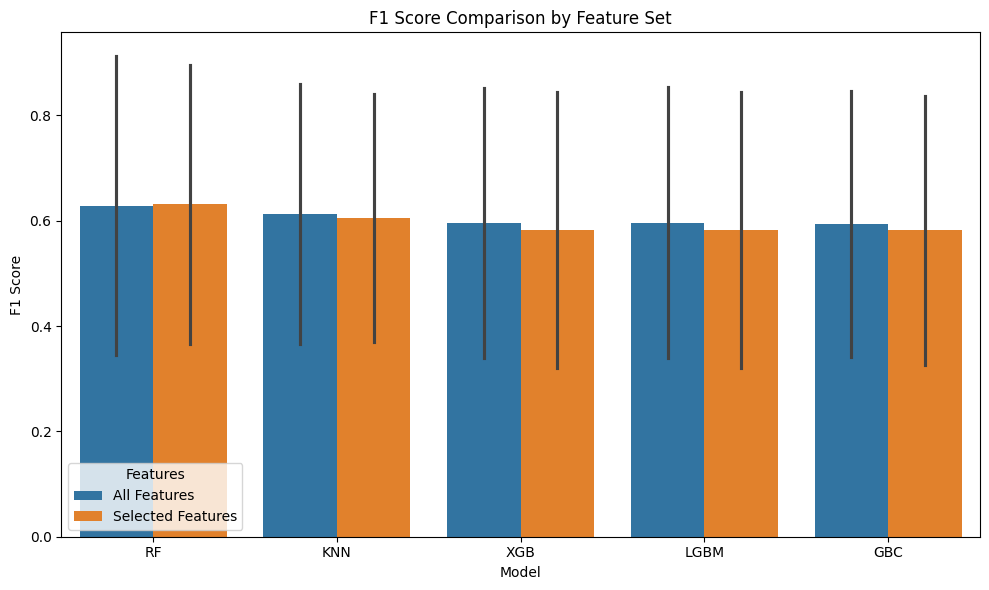

In [13]:
# --- Output Results ---
results_test_df = pd.DataFrame(results_test)
results_test_df = results_test_df.sort_values(by="F1", ascending=False)

print("\n--- Results for All Features ---")
print(results_test_df[results_test_df["Features"] == "All Features"].sort_values(by="F1", ascending=False))

print("\n--- Results for Selected Features ---")
print(results_test_df[results_test_df["Features"] == "Selected Features"].sort_values(by="F1", ascending=False))

print("\n--- Average Metrics by Model and Feature Set ---")
summary = results_test_df.groupby(["Model", "Features"])[
    ["F1", "Accuracy", "Precision", "Recall"]
].mean().unstack().round(4)
print(summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_test_df, x="Model", y="F1", hue="Features", ci="sd")
plt.title("F1 Score Comparison by Feature Set")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

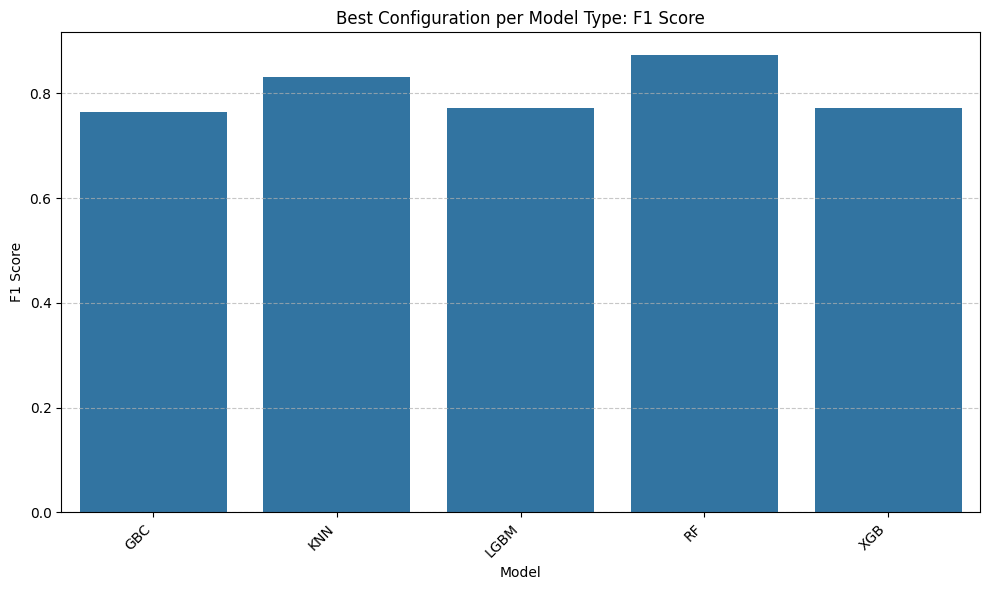

In [22]:
# Select best performing model per type (highest F1)
best_per_model = results_test_df.loc[results_test_df.groupby("Model")["F1"].idxmax()]

# Use a bar plot to visualize the best F1 scores
plt.figure(figsize=(10, 6))
sns.barplot(data=best_per_model, x='Model', y='F1')
plt.title('Best Configuration per Model Type: F1 Score')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

